In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set(style="whitegrid")


In [2]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

# Merge for full dataset
movie_data = pd.merge(ratings, movies, on='movieId')
movie_data.head()


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [3]:
print(f"Number of movies: {movies.shape[0]}")
print(f"Number of ratings: {ratings.shape[0]}")
print(f"Number of unique users: {ratings['userId'].nunique()}")
print(f"Number of unique movies rated: {ratings['movieId'].nunique()}")


Number of movies: 9742
Number of ratings: 100836
Number of unique users: 610
Number of unique movies rated: 9724


In [4]:
print("Missing values in movies:\n", movies.isnull().sum())
print("\nMissing values in ratings:\n", ratings.isnull().sum())


Missing values in movies:
 movieId    0
title      0
genres     0
dtype: int64

Missing values in ratings:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


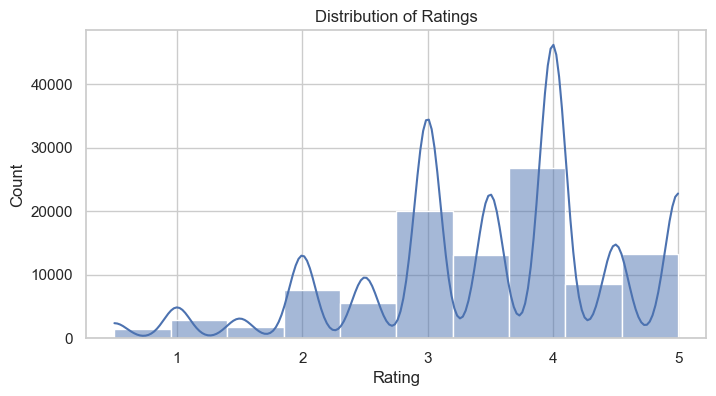

In [5]:
plt.figure(figsize=(8, 4))
sns.histplot(ratings['rating'], bins=10, kde=True)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


🎬 Most Popular Movie (by number of ratings):
                 title  num_ratings
0  Forrest Gump (1994)          329


C:\Users\VISHISHTA\AppData\Local\Temp\ipykernel_2960\789450751.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=popular_movies.head(10), x='num_ratings', y='title', palette='magma')


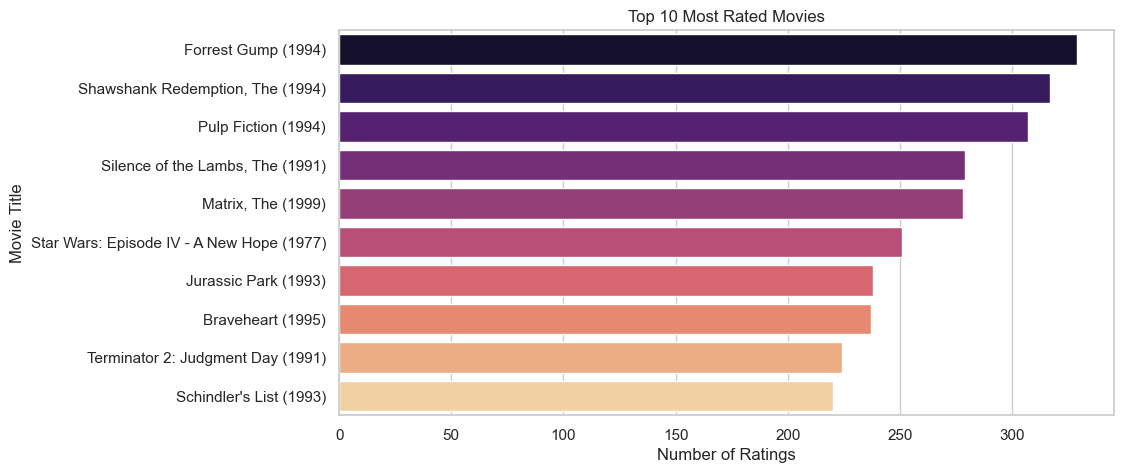

In [6]:
# Count number of ratings per movie
popular_movies = movie_data['title'].value_counts().reset_index()
popular_movies.columns = ['title', 'num_ratings']

# Display the most popular movie
most_popular = popular_movies.head(1)
print("🎬 Most Popular Movie (by number of ratings):")
print(most_popular)

# Plot top 10 most rated movies
plt.figure(figsize=(10, 5))
sns.barplot(data=popular_movies.head(10), x='num_ratings', y='title', palette='magma')
plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie Title")
plt.show()


⭐ Top 10 Movies by Average Rating (min 50 ratings):
                                                    avg_rating  num_ratings
title                                                                      
Shawshank Redemption, The (1994)                      4.429022          317
Godfather, The (1972)                                 4.289062          192
Fight Club (1999)                                     4.272936          218
Cool Hand Luke (1967)                                 4.271930           57
Dr. Strangelove or: How I Learned to Stop Worry...    4.268041           97
Rear Window (1954)                                    4.261905           84
Godfather: Part II, The (1974)                        4.259690          129
Departed, The (2006)                                  4.252336          107
Goodfellas (1990)                                     4.250000          126
Casablanca (1942)                                     4.240000          100


C:\Users\VISHISHTA\AppData\Local\Temp\ipykernel_2960\390970797.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_avg_rated.reset_index(), x='avg_rating', y='title', palette='coolwarm')


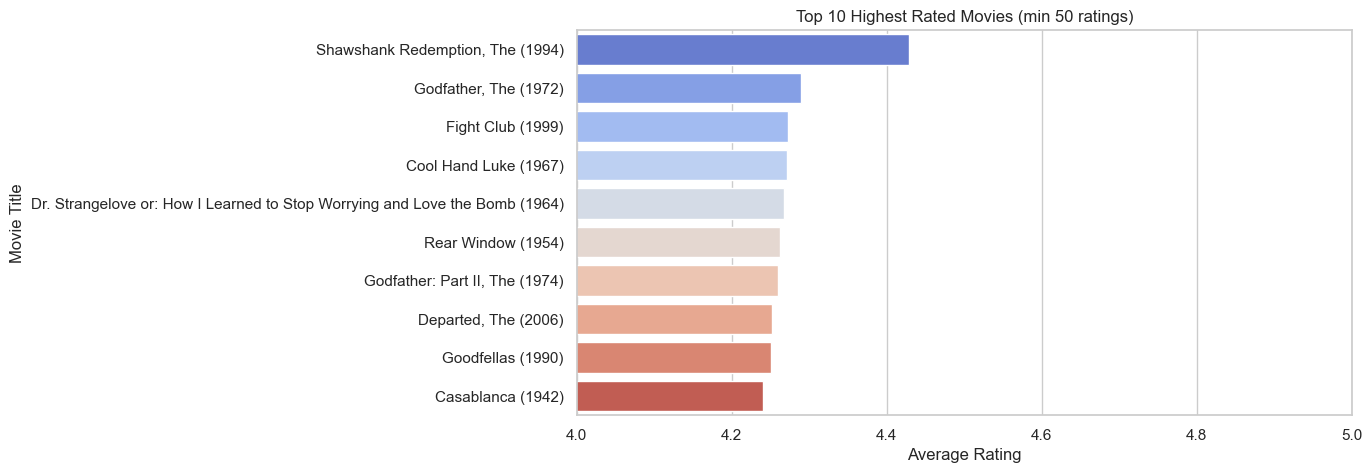

In [7]:
# Calculate average rating and rating count
movie_stats = movie_data.groupby('title').agg({
    'rating': ['mean', 'count']
})
movie_stats.columns = ['avg_rating', 'num_ratings']

# Filter: only movies with at least 50 ratings
filtered = movie_stats[movie_stats['num_ratings'] >= 50]

# Sort and get top 10
top_avg_rated = filtered.sort_values(by='avg_rating', ascending=False).head(10)

print("⭐ Top 10 Movies by Average Rating (min 50 ratings):")
print(top_avg_rated)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=top_avg_rated.reset_index(), x='avg_rating', y='title', palette='coolwarm')
plt.title("Top 10 Highest Rated Movies (min 50 ratings)")
plt.xlabel("Average Rating")
plt.ylabel("Movie Title")
plt.xlim(4.0, 5.0)
plt.show()


C:\Users\VISHISHTA\AppData\Local\Temp\ipykernel_2960\1699237483.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_df, x='Count', y='Genre', palette='viridis')


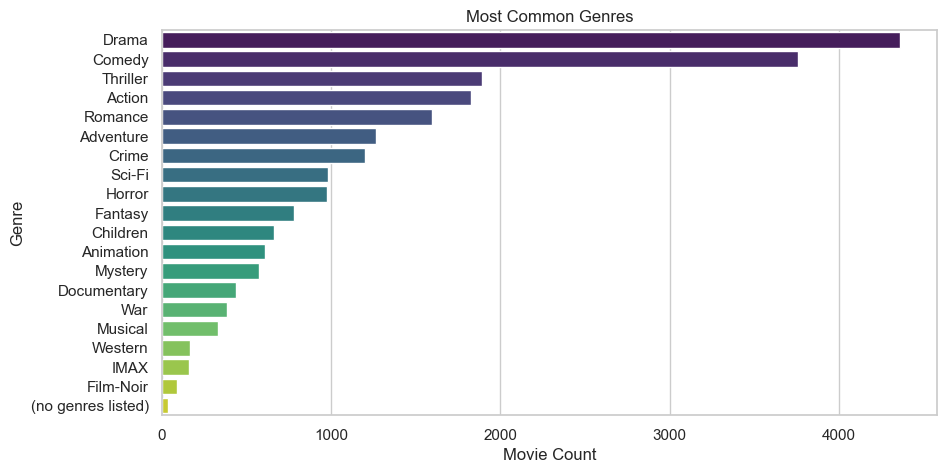

In [8]:
genre_counts = Counter()
for g_list in movies['genres']:
    for genre in g_list.split('|'):
        genre_counts[genre] += 1

genre_df = pd.DataFrame(genre_counts.items(), columns=['Genre', 'Count']).sort_values(by='Count', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=genre_df, x='Count', y='Genre', palette='viridis')
plt.title("Most Common Genres")
plt.xlabel("Movie Count")
plt.ylabel("Genre")
plt.show()


C:\Users\VISHISHTA\AppData\Local\Temp\ipykernel_2960\410232515.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_genre_rating, x='Average Rating', y='Genre', palette='coolwarm')


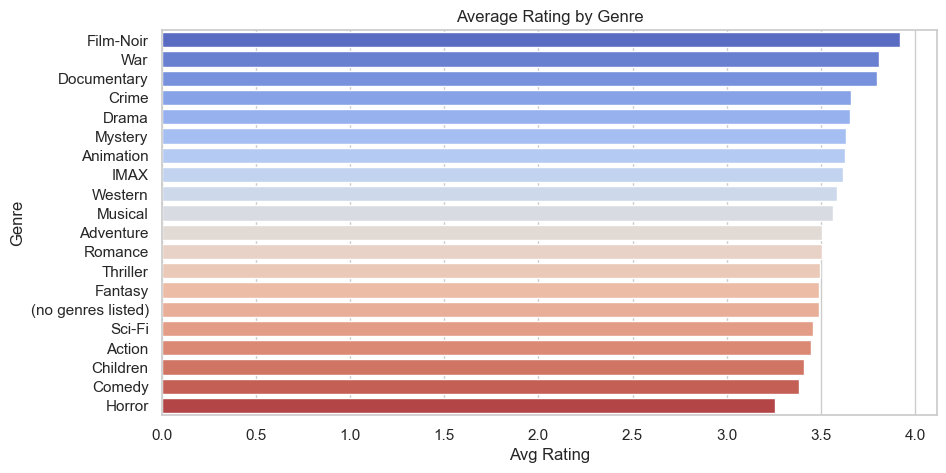

In [9]:
genre_rating = {}

for _, row in movie_data.iterrows():
    for genre in row['genres'].split('|'):
        if genre not in genre_rating:
            genre_rating[genre] = {'sum': 0, 'count': 0}
        genre_rating[genre]['sum'] += row['rating']
        genre_rating[genre]['count'] += 1

avg_genre_rating = pd.DataFrame({
    'Genre': list(genre_rating.keys()),
    'Average Rating': [v['sum'] / v['count'] for v in genre_rating.values()]
}).sort_values(by='Average Rating', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=avg_genre_rating, x='Average Rating', y='Genre', palette='coolwarm')
plt.title("Average Rating by Genre")
plt.xlabel("Avg Rating")
plt.ylabel("Genre")
plt.show()
